# MVP — Previsão de Custo de Garantia (Mês+1, Mês+2, Mês+3)

**Nome:** _Seu nome aqui_  
**Matrícula:** _Sua matrícula aqui_  
**Data:** _dd/mm/aaaa_  
**Dataset:** Ordens de Serviço de Garantia — Imbera Brasil (2022–2025)  
**Tipo de problema:** Séries Temporais / Forecasting com features de lag (ML-based)  

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão temporal adequada (sem embaralhamento) | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Features de lag e calendário criadas e justificadas | ☐ |
| Modelo baseline definido (média móvel) | ☐ |
| Pelo menos dois modelos comparados | ☐ |
| Avaliação com MAE e MAPE | ☐ |
| Discussão de limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

---
# 1. Definição do Problema

## 1.1 Descrição do problema

A Imbera Brasil fabrica congeladores e freezers comerciais (modelos EVZ21, EVF19, entre outros) que são distribuídos para clientes dos segmentos Foodservice, KOF e outros canais. Após a venda, os equipamentos entram em período de garantia, gerando ordens de serviço (OS) para atendimento técnico — com custos de peças, mão de obra e despesas adicionais.

O volume e o custo dessas OS variam ao longo do tempo, impactando diretamente o planejamento financeiro da área de pós-venda. Hoje, a empresa não possui um modelo preditivo para antecipar esses gastos, o que dificulta o provisionamento de recursos e a gestão de fornecedores de assistência técnica.

**Usuários da solução:** área financeira e de pós-venda da Imbera Brasil.  
**Relevância:** antecipar os custos de garantia permite melhor alocação de budget, negociação com prestadores e redução de surpresas financeiras.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever o custo total de garantia dos meses seguintes (mês+1, mês+2 e mês+3)** a partir do histórico mensal de ordens de serviço, comparando uma abordagem baseline (média móvel) com modelos candidatos baseados em features de lag e calendário, e discutindo suas limitações.

**Objetivo deste trabalho:**  
> _Preencha aqui com suas palavras após entender bem o problema._

## 1.3 Tipo de problema

**Tipo escolhido:** Séries Temporais / Forecasting (Regressão com features temporais)  
**Justificativa:** O target (`custo_total_mes`) é uma variável numérica contínua que evolui ao longo do tempo, com possível sazonalidade mensal e tendência. A ordem temporal dos dados é fundamental — embaralhar os registros causaria vazamento de dados (data leakage). Por isso, adotamos a abordagem de ML com features de lag, que transforma o problema de série temporal em um problema de regressão supervisionada preservando a ordem cronológica.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O custo de garantia apresenta sazonalidade mensal (ex.: picos em determinados meses do ano).
2. O custo dos meses anteriores (lags) é o principal preditor do custo futuro.
3. O volume de OS por mês está correlacionado com o custo total.

**Critérios de sucesso:**
- **Métrica principal:** MAPE (Mean Absolute Percentage Error) — intuitivo para comunicar ao negócio.
- **Métrica secundária:** MAE (Mean Absolute Error) — em reais, para dimensionar o erro absoluto.
- **Resultado mínimo esperado:** superar o baseline (média móvel) em pelo menos 10% no MAPE.
- **Restrição prática:** modelo simples o suficiente para ser re-treinado mensalmente com baixo custo computacional.

---
# 2. Ambiente, Bibliotecas e Reprodutibilidade

In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Python:', sys.version.split()[0])
print('Pandas:', pd.__version__)
print('Seed:', SEED)

Python: 3.12.13
Pandas: 2.2.2
Seed: 42


## 2.1 Funções auxiliares

In [2]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — evita divisão por zero."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(y_true, y_pred, model_name='modelo'):
    """Calcula MAE, RMSE, R2 e MAPE para regressão/forecasting."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mp   = mape(y_true, y_pred)
    return {'Modelo': model_name, 'MAE (R$)': round(mae, 2),
            'RMSE (R$)': round(rmse, 2), 'R2': round(r2, 4),
            'MAPE (%)': round(mp, 2)}


def plot_forecast(df_monthly, y_pred_dict, horizon_label):
    """Plota série real vs previsões para um horizonte."""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_monthly['ano_mes'], df_monthly['custo_total'],
            marker='o', label='Real', linewidth=2)
    colors = ['tomato', 'steelblue', 'seagreen', 'orange']
    for (name, preds), color in zip(y_pred_dict.items(), colors):
        ax.plot(df_monthly['ano_mes'].iloc[-len(preds):],
                preds, marker='s', linestyle='--',
                label=name, color=color)
    ax.set_title(f'Custo Real vs Previsto — {horizon_label}')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Custo Total (R$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'R$ {x:,.0f}'))
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


print('Funções auxiliares carregadas.')

Funções auxiliares carregadas.


---
# 3. Carga dos Dados

## 3.1 Fonte dos dados

- **Dataset:** Ordens de Serviço de Garantia — Imbera Brasil
- **Período:** Janeiro/2022 a Junho/2025 (aproximadamente)
- **Volume:** ~50.000+ registros
- **Fonte:** Sistema interno de gestão de pós-venda da Imbera
- **Restrições:** Dados confidenciais — não publicar em repositórios abertos. Para execução no Colab, carregar via Google Drive ou upload direto.
- **Privacidade:** Contém nome de prestadores de serviço e clientes — anonimizar se necessário para apresentação.

> **TODO:** Substituir o bloco abaixo pelo carregamento real da sua base.

## 3.2 Visão geral do dataset
# ============================================================
# CARGA DOS DADOS — direto do GitHub
# ============================================================
import io
import requests
import re

DATE_COL = 'Mês Fechamento - KOF'
COST_COL = 'SOMA DE GASTOS'

# URL raw do arquivo no GitHub
url = 'https://raw.githubusercontent.com/marcossilvalopesimbera-rgb/mvp-custo-garantia/main/base_garantia_MVP.xlsx'

print('Carregando base do GitHub...')
response = requests.get(url)
df_raw = pd.read_excel(io.BytesIO(response.content), sheet_name='base_os')

# === Limpeza das colunas monetárias ===
def limpar_moeda(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    s = re.sub(r'R\$', '', s)
    s = re.sub(r'\s+', '', s)
    s = s.replace('.', '').replace(',', '.').replace('-', '0')
    try:
        return float(s)
    except:
        return np.nan

for col in ['Gastos com peças', 'MÃO DE OBRA', 'Valor Adicional', COST_COL]:
    df_raw[col] = df_raw[col].apply(limpar_moeda)

# === Padronizar datas ===
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors='coerce')
df_raw = df_raw.dropna(subset=[DATE_COL])
df_raw = df_raw[df_raw[COST_COL] >= 0]

print(f'✅ Base carregada com {len(df_raw)} linhas')
print(f'Período: {df_raw[DATE_COL].min().strftime("%b/%Y")} a {df_raw[DATE_COL].max().strftime("%b/%Y")}')
df_raw.head(3)

In [3]:
import io
import requests
import re
import openpyxl # Adicionado para especificar o motor do excel

DATE_COL = 'Mês Fechamento - KOF'
COST_COL = 'SOMA DE GASTOS'

# URL raw do arquivo no GitHub
url = 'https://raw.githubusercontent.com/marcossilvalopesimbera-rgb/mvp-custo-garantia/main/base_garantia_MVP.xlsx'

print('Carregando base do GitHub...')
response = requests.get(url, allow_redirects=True)
print(f'Status: {response.status_code} | Tamanho: {len(response.content)/1024/1024:.1f} MB')

# === DEBUGGING OUTPUT ===
print('\n--- Headers da Resposta ---')
for header, value in response.headers.items():
    print(f'{header}: {value}')
print('\n--- Primeiros 500 bytes do Conteúdo ---')
print(response.content[:500])
print('--- Fim do Conteúdo ---\n')
# === END DEBUGGING OUTPUT ===

# Verifica se o download foi bem-sucedido e se o conteúdo não está vazio
if response.status_code != 200:
    raise requests.exceptions.RequestException(f"Erro ao baixar o arquivo: Status {response.status_code}")
if len(response.content) == 0:
    print("ERRO: O conteúdo baixado do GitHub está vazio, apesar do status 200.")
    print("Isso pode ser um problema temporário de rede ou com o GitHub. Por favor, tente novamente.")
    print("Se o problema persistir, baixe o arquivo manualmente do link abaixo e carregue-o para o Colab:")
    print(f"Link para download manual: {url}")
    print("Em seguida, edite esta célula para ler o arquivo local (após carregá-lo), por exemplo:")
    print("  # from google.colab import files")
    print("  # uploaded = files.upload()")
    print("  # df_raw = pd.read_excel('base_garantia_MVP.xlsx', sheet_name='base_os', engine='openpyxl')")
    raise ValueError("Conteúdo do arquivo Excel vazio, impossível processar.")

df_raw = pd.read_excel(io.BytesIO(response.content), sheet_name='base_os', engine='openpyxl')

def limpar_moeda(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    s = re.sub(r'R\\$', '', s)
    s = re.sub(r'\\s+', '', s)
    s = s.replace('.', '').replace(',', '.').replace('-', '0')
    try:
        return float(s)
    except:
        return np.nan

for col in ['Gastos com peças', 'MÃO DE OBRA', 'Valor Adicional', COST_COL]:
    df_raw[col] = df_raw[col].apply(limpar_moeda)

df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors='coerce')
df_raw = df_raw.dropna(subset=[DATE_COL])
df_raw = df_raw[df_raw[COST_COL] >= 0]

print(f'✅ Base carregada com {len(df_raw)} linhas')
print(f'Período: {df_raw[DATE_COL].min().strftime("%b/%Y")} a {df_raw[DATE_COL].max().strftime("%b/%Y")}')
df_raw.head(3)

Carregando base do GitHub...
Status: 200 | Tamanho: 6.4 MB

--- Headers da Resposta ---
Connection: keep-alive
Content-Length: 6722748
Cache-Control: max-age=300
Content-Security-Policy: default-src 'none'; style-src 'unsafe-inline'; sandbox
Content-Type: application/octet-stream
ETag: W/"e062e1d056dd555f84400112a3b6ed271b072f14c179279e73aa6c70c3032171"
Strict-Transport-Security: max-age=31536000
X-Content-Type-Options: nosniff
X-Frame-Options: deny
X-XSS-Protection: 1; mode=block
X-GitHub-Request-Id: 3A5C:87269:21435A5:25712C2:6A19B565
Accept-Ranges: bytes
Date: Fri, 29 May 2026 15:48:54 GMT
Via: 1.1 varnish
X-Served-By: cache-ams2100101-AMS
X-Cache: MISS
X-Cache-Hits: 0
X-Timer: S1780069734.469925,VS0,VE463
Vary: Authorization,Accept-Encoding
Access-Control-Allow-Origin: *
Cross-Origin-Resource-Policy: cross-origin
X-Fastly-Request-ID: 0e47cdfad5bfabac28b483f623c9b6f2c55272ce
Expires: Fri, 29 May 2026 15:53:54 GMT
Source-Age: 0

--- Primeiros 500 bytes do Conteúdo ---
b'PK\x03\x04\x1

,OS,Mês Fechamento - KOF,Produto,FAMÍLIA DO PRODUTO,Produto ajustado,n° de série,Defeito Constatado,Classificação cliente,Cliente ajustado,Gastos com peças,MÃO DE OBRA,Valor Adicional,SOMA DE GASTOS
0,62719069,2023-01-01,1023713-ENF VRS19 C BMAE 220V LED PRE SHELL,REFRIGERADOR,VRS19,G57221160683,Motor do condensador com defeito,TERCEIROS,KOF,51.683174,100.0,NaN,103.130000
1,62609606,2023-01-01,1023546-ENF VR08 C BMAE R2 220V LL TGAL FS EST,REFRIGERADOR,VR08,E74210560970,Reservatório de água cheio,FOODSERVICE,KOF,0.000000,110.0,NaN,268.872576
2,62569897,2023-01-01,1023717-PRO CCV355 C BMAE 220V CF LL SHELL,REFRIGERADOR,CCV355,G56221060401,"Unidade de refrigeração sem gás, Sensor de tem...",TERCEIROS,KOF,0.000000,474.0,NaN,57.824961


## 3.3 Dicionário de dados

| Coluna | Tipo | Descrição | Usada no modelo? |
|---|---|---|---|
| OS | ID | Número da ordem de serviço | Não — identificador |
| Mês Fechamento - KOF | Data | Mês de encerramento da OS | Sim — base temporal |
| FAMÍLIA DO PRODUTO | Categórico | Tipo do produto (Congelador, Refrigerador) | Não na série agregada |
| Produto ajustado | Categórico | Modelo do equipamento (EVZ21, EVF19...) | Não na série agregada |
| Defeito Constatado | Texto | Tipo de defeito relatado | Não na série agregada |
| Classificação cliente | Categórico | Segmento do cliente | Não na série agregada |
| SOMA DE GASTOS | Numérico | Custo total da OS (peças + MO + adicional) | **TARGET** (após agregar por mês) |
| Gastos com peças | Numérico | Custo de peças da OS | Componente do target |
| MÃO DE OBRA | Numérico | Custo de mão de obra da OS | Componente do target |
| Valor Adicional | Numérico | Despesas adicionais | Componente do target |

---
# 4. Análise Exploratória dos Dados (EDA)

In [4]:
# === Padronizar coluna de data e limpar valores monetários ===
# Ajuste o nome da coluna de data conforme sua base real
DATE_COL = 'Mês Fechamento - KOF'
COST_COL = 'SOMA DE GASTOS'

df = df_raw.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

# Se a coluna de custo for string com 'R$', descomente e ajuste:
# df[COST_COL] = (df[COST_COL].astype(str)
#                 .str.replace('R\$', '', regex=True)
#                 .str.replace('.', '', regex=False)
#                 .str.replace(',', '.', regex=False)
#                 .str.strip()
#                 .astype(float))

df = df.dropna(subset=[DATE_COL, COST_COL])
df = df[df[COST_COL] >= 0]   # remover valores negativos inválidos

print('Período:', df[DATE_COL].min().strftime('%b/%Y'), 'até', df[DATE_COL].max().strftime('%b/%Y'))
print('Registros válidos:', len(df))

Período: Jan/2023 até May/2026
Registros válidos: 90741


In [5]:
# === Agregar por mês ===
df['ano_mes'] = df[DATE_COL].dt.to_period('M')

df_monthly = (
    df.groupby('ano_mes')
    .agg(
        custo_total=(COST_COL, 'sum'),
        volume_os=(COST_COL, 'count'),
        ticket_medio=(COST_COL, 'mean'),
        custo_pecas=('Gastos com peças', 'sum') if 'Gastos com peças' in df.columns else (COST_COL, 'sum'),
        custo_mo=('MÃO DE OBRA', 'sum') if 'MÃO DE OBRA' in df.columns else (COST_COL, 'sum'),
    )
    .reset_index()
    .sort_values('ano_mes')
)

df_monthly['ano_mes_dt'] = df_monthly['ano_mes'].dt.to_timestamp()

print('Meses disponíveis:', len(df_monthly))
display(df_monthly.head(6))

Meses disponíveis: 41


,ano_mes,custo_total,volume_os,ticket_medio,custo_pecas,custo_mo,ano_mes_dt
0,2023-01,157628.938417,1740,90.591344,120724.011188,171522.77,2023-01-01
1,2023-02,179873.361286,1765,101.911253,101257.303300,179857.19,2023-02-01
2,2023-03,144403.091159,1411,102.340958,81334.605094,129859.20,2023-03-01
3,2023-04,163622.153533,1688,96.932555,95888.777132,138773.96,2023-04-01
4,2023-05,127898.569920,1266,101.025727,73142.828008,90270.59,2023-05-01
5,2023-06,205835.966023,1302,158.092140,80388.526946,101487.40,2023-06-01


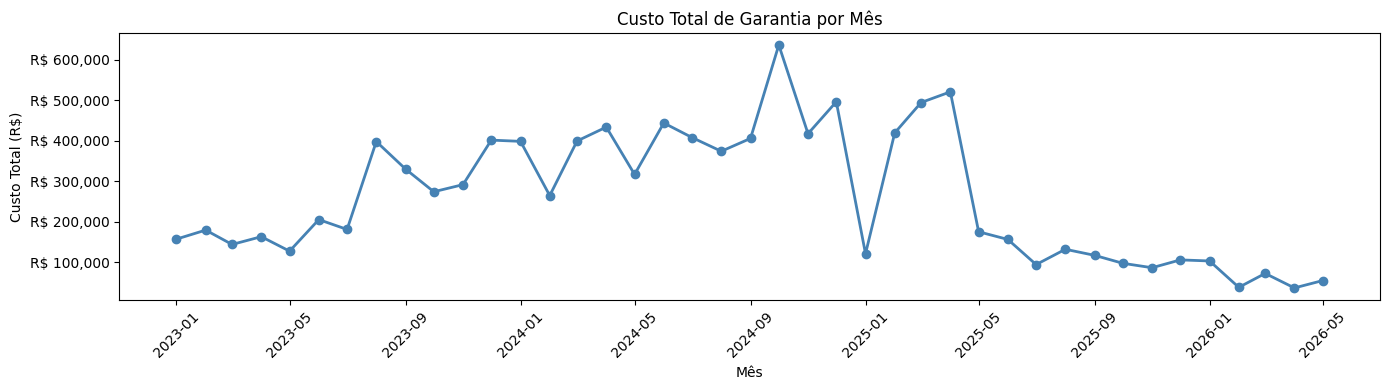

Custo médio mensal: R$ 260,821.78
Custo mínimo:       R$ 37,043.32
Custo máximo:       R$ 637,071.44


In [6]:
# === Gráfico 1: Série histórica de custo total ===
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_monthly['ano_mes_dt'], df_monthly['custo_total'],
        marker='o', linewidth=2, color='steelblue')
ax.set_title('Custo Total de Garantia por Mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Custo Total (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Custo médio mensal: R$ {df_monthly['custo_total'].mean():,.2f}")
print(f"Custo mínimo:       R$ {df_monthly['custo_total'].min():,.2f}")
print(f"Custo máximo:       R$ {df_monthly['custo_total'].max():,.2f}")

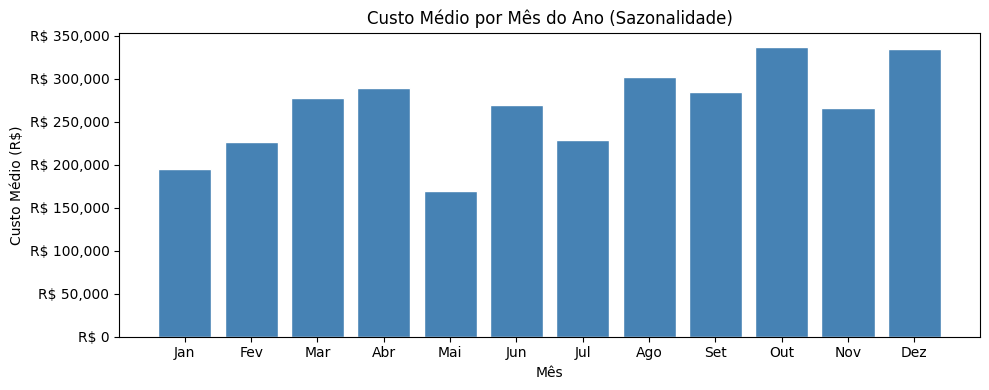

In [7]:
# === Gráfico 2: Sazonalidade mensal ===
df_monthly['mes_num'] = df_monthly['ano_mes'].dt.month
sazon = df_monthly.groupby('mes_num')['custo_total'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sazon.index, sazon.values, color='steelblue', edgecolor='white')
ax.set_title('Custo Médio por Mês do Ano (Sazonalidade)')
ax.set_xlabel('Mês')
ax.set_ylabel('Custo Médio (R$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                     'Jul','Ago','Set','Out','Nov','Dez'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()

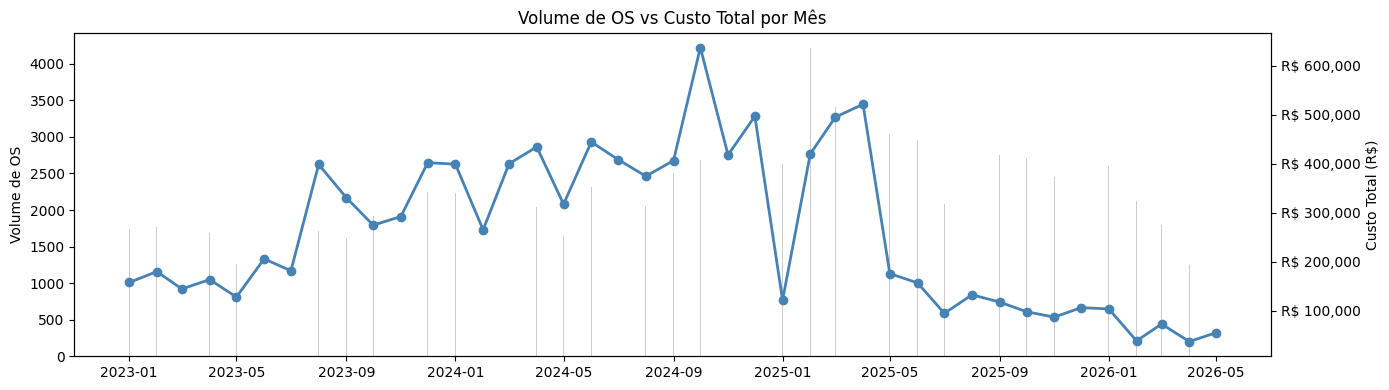

In [8]:
# === Gráfico 3: Volume de OS vs Custo Total ===
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(df_monthly['ano_mes_dt'], df_monthly['volume_os'],
        alpha=0.4, color='gray', label='Volume de OS')
ax2.plot(df_monthly['ano_mes_dt'], df_monthly['custo_total'],
         color='steelblue', marker='o', linewidth=2, label='Custo Total')
ax1.set_ylabel('Volume de OS')
ax2.set_ylabel('Custo Total (R$)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax1.set_title('Volume de OS vs Custo Total por Mês')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

**Preencha após observar os gráficos acima:**

- A série apresenta tendência de crescimento, estabilidade ou queda?
- Há sazonalidade visível? Em quais meses o custo tende a ser maior?
- Volume de OS e custo total andam juntos? Ou o ticket médio varia bastante?
- Há outliers ou meses atípicos que merecem atenção?

**Síntese:**  
> _Preencha aqui após analisar os gráficos com sua base real._

---
# 5. Engenharia de Features e Divisão Temporal

In [9]:
# === Criação de features de lag e calendário ===
# Estratégia: transformar o problema de série temporal em regressão supervisionada.
# Cada linha representa um mês; as features são os custos dos meses anteriores (lags)
# e indicadores de calendário (mês, trimestre).

df_feat = df_monthly[['ano_mes', 'ano_mes_dt', 'custo_total', 'volume_os', 'ticket_medio']].copy()

# Features de lag — custo dos meses anteriores
for lag in [1, 2, 3, 6, 12]:
    df_feat[f'lag_{lag}'] = df_feat['custo_total'].shift(lag)

# Médias móveis — suavizam ruído e capturam tendência
df_feat['mm3']  = df_feat['custo_total'].shift(1).rolling(window=3).mean()
df_feat['mm6']  = df_feat['custo_total'].shift(1).rolling(window=6).mean()
df_feat['mm12'] = df_feat['custo_total'].shift(1).rolling(window=12).mean()

# Features de calendário
df_feat['mes_num']    = df_feat['ano_mes'].dt.month
df_feat['trimestre']  = df_feat['ano_mes'].dt.quarter
df_feat['ano']        = df_feat['ano_mes'].dt.year

# Variação percentual mês a mês (momentum)
df_feat['variacao_pct_1'] = df_feat['custo_total'].pct_change(1).shift(1)
df_feat['variacao_pct_3'] = df_feat['custo_total'].pct_change(3).shift(1)

# Volume de OS do mês anterior (preditor adicional)
df_feat['volume_lag1'] = df_feat['volume_os'].shift(1)
df_feat['volume_lag2'] = df_feat['volume_os'].shift(2)

# Remover linhas com NaN geradas pelos lags
df_feat = df_feat.dropna().reset_index(drop=True)

print('Meses disponíveis após criação de features:', len(df_feat))
display(df_feat.head(3))

Meses disponíveis após criação de features: 29


,ano_mes,ano_mes_dt,custo_total,volume_os,ticket_medio,lag_1,lag_2,lag_3,lag_6,lag_12,mm3,mm6,mm12,mes_num,trimestre,ano,variacao_pct_1,variacao_pct_3,volume_lag1,volume_lag2
0,2024-01,2024-01-01,399053.496370,2232,178.787409,402122.666439,292152.157254,274590.427181,181506.733888,157628.938417,322955.083624,313274.957418,238242.652070,1,1,2024,0.376415,0.215965,2247.0,1686.0
1,2024-02,2024-02-01,265118.800704,1514,175.111493,399053.496370,402122.666439,292152.157254,398575.219747,179873.361286,364442.773354,349532.751165,258361.365233,2,1,2024,-0.007632,0.453268,2232.0,2247.0
2,2024-03,2024-03-01,399955.196444,2061,194.058805,265118.800704,399053.496370,402122.666439,330702.540000,144403.091159,355431.654504,327290.014658,265465.151851,3,1,2024,-0.335631,-0.092532,1514.0,2232.0


In [10]:
# === Criação dos targets para mês+1, mês+2 e mês+3 ===
# Abordagem: Direct Multi-Step — um modelo separado para cada horizonte.
# É mais simples e evita acumulação de erros da abordagem recursiva.

df_feat['target_h1'] = df_feat['custo_total'].shift(-1)  # mês+1
df_feat['target_h2'] = df_feat['custo_total'].shift(-2)  # mês+2
df_feat['target_h3'] = df_feat['custo_total'].shift(-3)  # mês+3

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'mm3', 'mm6', 'mm12',
    'mes_num', 'trimestre', 'ano',
    'variacao_pct_1', 'variacao_pct_3',
    'volume_lag1', 'volume_lag2'
]

print('Features usadas no modelo:', FEATURE_COLS)
print('Targets: target_h1 (mês+1), target_h2 (mês+2), target_h3 (mês+3)')

Features usadas no modelo: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'mm3', 'mm6', 'mm12', 'mes_num', 'trimestre', 'ano', 'variacao_pct_1', 'variacao_pct_3', 'volume_lag1', 'volume_lag2']
Targets: target_h1 (mês+1), target_h2 (mês+2), target_h3 (mês+3)


In [11]:
# === Divisão temporal treino / teste ===
# IMPORTANTE: nunca embaralhar dados de série temporal!
# Usamos os últimos 6 meses como teste (holdout temporal).

N_TEST = 6   # últimos N meses como conjunto de teste

# Para cada horizonte, descartamos as últimas linhas sem target válido
def split_horizon(df, target_col, n_test):
    df_h = df.dropna(subset=[target_col]).copy()
    train = df_h.iloc[:-n_test]
    test  = df_h.iloc[-n_test:]
    return train, test

train_h1, test_h1 = split_horizon(df_feat, 'target_h1', N_TEST)
train_h2, test_h2 = split_horizon(df_feat, 'target_h2', N_TEST)
train_h3, test_h3 = split_horizon(df_feat, 'target_h3', N_TEST)

print(f'Horizonte +1 — Treino: {len(train_h1)} meses | Teste: {len(test_h1)} meses')
print(f'Horizonte +2 — Treino: {len(train_h2)} meses | Teste: {len(test_h2)} meses')
print(f'Horizonte +3 — Treino: {len(train_h3)} meses | Teste: {len(test_h3)} meses')
print(f'\nPeríodo de teste: {test_h1["ano_mes"].min()} a {test_h1["ano_mes"].max()}')

Horizonte +1 — Treino: 22 meses | Teste: 6 meses
Horizonte +2 — Treino: 21 meses | Teste: 6 meses
Horizonte +3 — Treino: 20 meses | Teste: 6 meses

Período de teste: 2025-11 a 2026-04


## 5.1 Justificativa da divisão

A divisão é estritamente temporal: os **últimos 6 meses** formam o conjunto de teste e todos os meses anteriores compõem o treino. Isso simula o cenário real de uso — o modelo é treinado com dados históricos e avaliado em meses que ele "nunca viu".

**Por que não embaralhar?** Em séries temporais, embaralhar causa vazamento de dados (data leakage): o modelo poderia "aprender" com o futuro, gerando métricas artificialmente boas que não se repetem em produção.

**Por que 3 modelos separados (Direct Multi-Step)?** É mais simples e robusto do que a abordagem recursiva (onde o erro do mês+1 alimenta a previsão do mês+2). Cada modelo é especializado em seu horizonte.

---
# 6. Baseline

In [12]:
# === Baseline: Média Móvel dos últimos 3 meses ===
# Interpretação: "o próximo mês vai custar o mesmo que a média dos 3 últimos meses".
# É o benchmark mínimo — qualquer modelo deve superá-lo para justificar sua complexidade.

results_all = []

for horizon, (train, test) in enumerate([
    (train_h1, test_h1),
    (train_h2, test_h2),
    (train_h3, test_h3)
], start=1):
    target_col = f'target_h{horizon}'
    y_test = test[target_col].values
    y_baseline = test['mm3'].values   # média móvel de 3 meses já está no dataset
    res = evaluate_forecast(y_test, y_baseline, model_name=f'Baseline MM3 (H+{horizon})')
    results_all.append(res)

pd.DataFrame(results_all)

,Modelo,MAE (R$),RMSE (R$),R2,MAPE (%)
0,Baseline MM3 (H+1),26565.13,33103.88,-0.3852,58.85
1,Baseline MM3 (H+2),32825.61,39341.68,-0.9565,72.03
2,Baseline MM3 (H+3),40361.27,46360.72,-1.7169,85.36


---
# 7. Modelos Candidatos

## 7.1 Justificativa dos modelos

| Modelo | Justificativa |
|---|---|
| **Ridge Regression** | Linear, rápido, interpretável. Bom ponto de partida para séries sem muita não-linearidade. A regularização L2 evita overfitting com poucas amostras mensais. |
| **Random Forest Regressor** | Captura não-linearidades e interações entre features (ex.: sazonalidade + lag combinados). Robusto a outliers. |
| **Gradient Boosting Regressor** | Geralmente o modelo com melhor performance em dados tabulares. Mais sensível a hiperparâmetros, mas pode superar os anteriores com ajuste adequado. |

In [13]:
# === Treinamento e avaliação — todos os modelos, todos os horizontes ===

models = {
    'Ridge':            Ridge(alpha=1.0),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=SEED),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED),
}

trained = {}   # armazena os modelos treinados por (modelo, horizonte)
results_models = []

for horizon, (train, test) in enumerate([
    (train_h1, test_h1),
    (train_h2, test_h2),
    (train_h3, test_h3)
], start=1):
    target_col = f'target_h{horizon}'
    X_train = train[FEATURE_COLS]
    y_train = train[target_col]
    X_test  = test[FEATURE_COLS]
    y_test  = test[target_col].values

    for name, model in models.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        elapsed = round(time.time() - t0, 3)
        y_pred = model.predict(X_test)
        res = evaluate_forecast(y_test, y_pred, model_name=f'{name} (H+{horizon})')
        res['Tempo (s)'] = elapsed
        results_models.append(res)
        trained[(name, horizon)] = (model, test, y_pred, target_col)

df_results = pd.DataFrame(results_models)
display(df_results.sort_values(['Modelo']))

,Modelo,MAE (R$),RMSE (R$),R2,MAPE (%),Tempo (s)
2,GradientBoosting (H+1),113455.51,136352.13,-22.5013,242.33,0.086
5,GradientBoosting (H+2),136346.93,166497.07,-34.0413,292.21,0.072
8,GradientBoosting (H+3),180775.34,197345.23,-48.2289,344.94,0.072
1,RandomForest (H+1),161693.26,174802.64,-37.6245,324.52,0.128
4,RandomForest (H+2),174814.52,186875.93,-43.1442,340.35,0.124
7,RandomForest (H+3),174302.56,183628.03,-41.6231,340.77,0.124
0,Ridge (H+1),254419.97,266457.28,-88.7475,414.51,0.023
3,Ridge (H+2),266932.77,296710.54,-110.2841,465.85,0.002
6,Ridge (H+3),104496.35,112447.94,-14.9834,203.63,0.002


In [14]:
# === Tabela resumo comparativa por horizonte ===
df_compare = pd.concat([
    pd.DataFrame(results_all),
    df_results
]).reset_index(drop=True)

print('=== MAPE (%) — menor é melhor ===')
pivot = df_compare.pivot_table(index='Modelo', values='MAPE (%)')
display(pivot.sort_values('MAPE (%)'))

=== MAPE (%) — menor é melhor ===


,MAPE (%)
Modelo,
Baseline MM3 (H+1),58.85
Baseline MM3 (H+2),72.03
Baseline MM3 (H+3),85.36
Ridge (H+3),203.63
GradientBoosting (H+1),242.33
GradientBoosting (H+2),292.21
RandomForest (H+1),324.52
RandomForest (H+2),340.35
RandomForest (H+3),340.77


## 7.2 Análise dos resultados iniciais

**Preencha após observar a tabela acima:**

- Algum modelo superou o baseline de forma consistente?
- O MAPE aumenta conforme o horizonte (H+1 → H+3)? Isso é esperado?
- O Random Forest ou Gradient Boosting se saíram melhor que o Ridge? Por quê isso faz sentido?

**Resposta:**  
> _Preencha aqui._

---
# 8. Visualização das Previsões

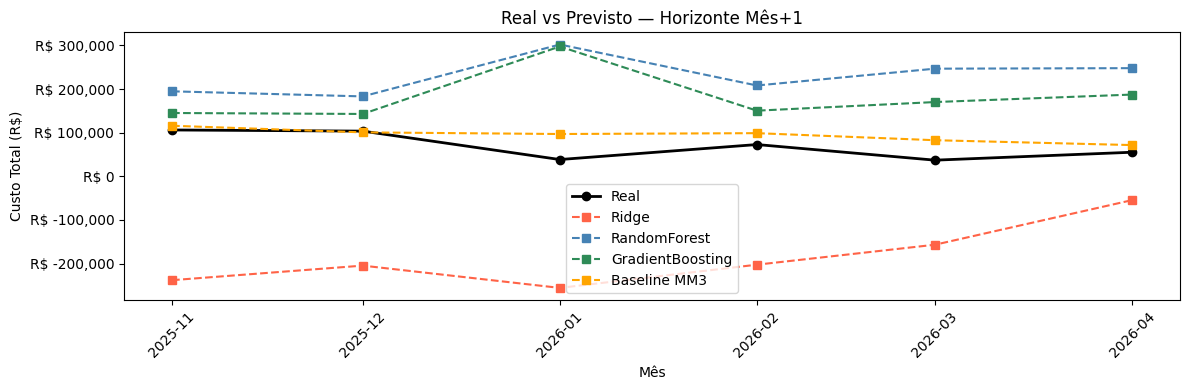

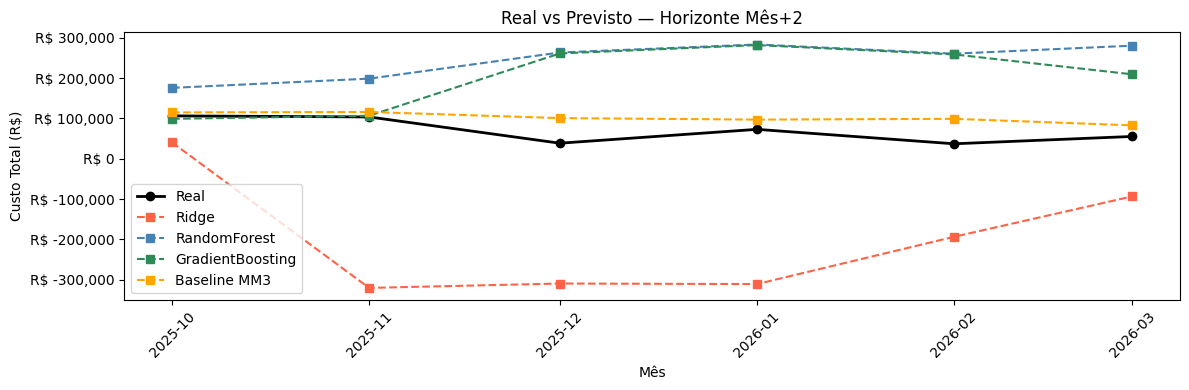

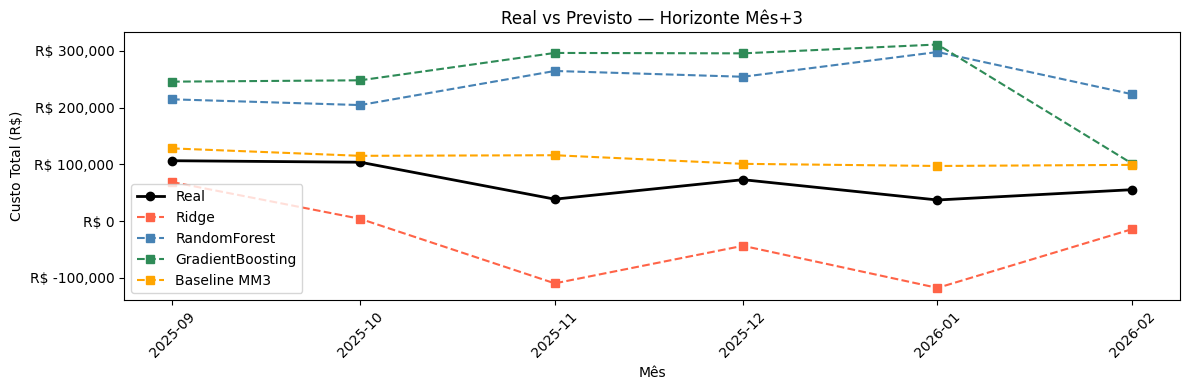

In [15]:
# === Plotar real vs previsto para cada horizonte ===

for horizon in [1, 2, 3]:
    preds_dict = {}
    test_ref = None
    for name in models:
        model, test, y_pred, target_col = trained[(name, horizon)]
        preds_dict[name] = y_pred
        test_ref = test

    # Baseline
    preds_dict['Baseline MM3'] = test_ref['mm3'].values

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))
    y_real = test_ref[f'target_h{horizon}'].values
    x_axis = test_ref['ano_mes_dt'].values
    ax.plot(x_axis, y_real, marker='o', linewidth=2, label='Real', color='black')
    colors = ['tomato', 'steelblue', 'seagreen', 'orange']
    for (nm, pred), color in zip(preds_dict.items(), colors):
        ax.plot(x_axis, pred, marker='s', linestyle='--', label=nm, color=color)
    ax.set_title(f'Real vs Previsto — Horizonte Mês+{horizon}')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Custo Total (R$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---
# 9. Otimização de Hiperparâmetros (Modelo Escolhido)

In [16]:
# === Otimização do GradientBoosting para o horizonte H+1 ===
# Usamos TimeSeriesSplit para preservar a ordem temporal na validação cruzada.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators':    randint(50, 300),
    'max_depth':       randint(2, 8),
    'learning_rate':   uniform(0.01, 0.2),
    'min_samples_split': randint(2, 10),
    'subsample':       uniform(0.6, 0.4)
}

gb_base = GradientBoostingRegressor(random_state=SEED)

search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

X_train_h1 = train_h1[FEATURE_COLS]
y_train_h1 = train_h1['target_h1']

search.fit(X_train_h1, y_train_h1)

print('\nMelhor MAE na validação: R$', round(-search.best_score_, 2))
print('Melhores hiperparâmetros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhor MAE na validação: R$ 155466.49
Melhores hiperparâmetros:
  learning_rate: 0.023010318597055907
  max_depth: 5
  min_samples_split: 2
  n_estimators: 109
  subsample: 0.8253152871382157


## 9.1 Discussão da otimização

**Perguntas para responder:**

- A otimização melhorou o MAPE em relação ao modelo inicial?
- O TimeSeriesSplit é adequado aqui? Por que não usar KFold tradicional?
- Quais hiperparâmetros tiveram mais impacto?

**Resposta:**  
> _Preencha aqui._

---
# 10. Avaliação Final

In [17]:
# === Avaliar modelo otimizado no conjunto de teste (H+1) ===
best_model_h1 = search.best_estimator_
X_test_h1 = test_h1[FEATURE_COLS]
y_test_h1 = test_h1['target_h1'].values

y_pred_best = best_model_h1.predict(X_test_h1)
res_best = evaluate_forecast(y_test_h1, y_pred_best, 'GB Otimizado (H+1)')

print('=== Resultado Final — Modelo Otimizado (Horizonte Mês+1) ===')
display(pd.DataFrame([res_best]))

# Comparar com baseline
res_bl = results_all[0]  # baseline H+1
mape_melhora = res_bl['MAPE (%)'] - res_best['MAPE (%)']
print(f"\nMelhora sobre o baseline: {mape_melhora:.2f} p.p. de MAPE")
if mape_melhora > 0:
    print('✅ Modelo superou o baseline.')
else:
    print('⚠️  Modelo não superou o baseline — revisar features ou tentar mais dados.')

=== Resultado Final — Modelo Otimizado (Horizonte Mês+1) ===


,Modelo,MAE (R$),RMSE (R$),R2,MAPE (%)
0,GB Otimizado (H+1),117886.05,135585.78,-22.2378,244.32



Melhora sobre o baseline: -185.47 p.p. de MAPE
⚠️  Modelo não superou o baseline — revisar features ou tentar mais dados.


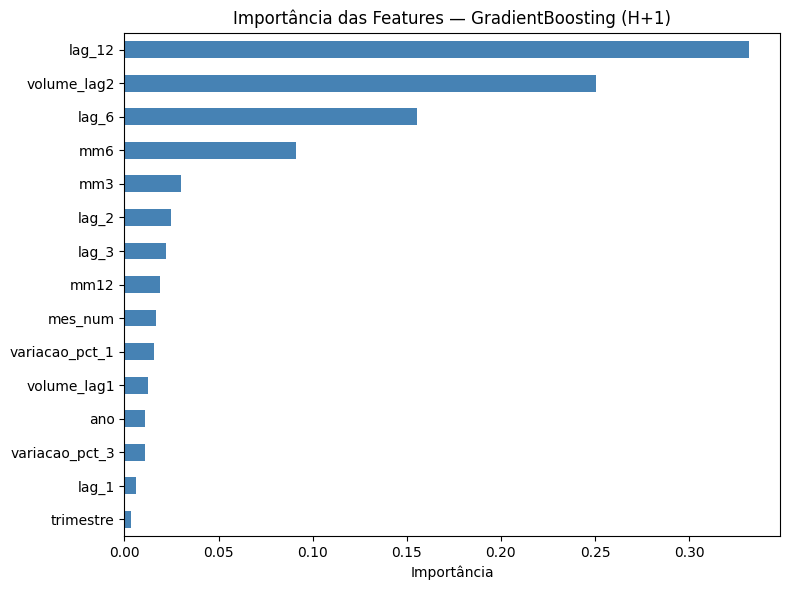

In [18]:
# === Importância das features ===
feat_imp = pd.Series(
    best_model_h1.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância das Features — GradientBoosting (H+1)')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

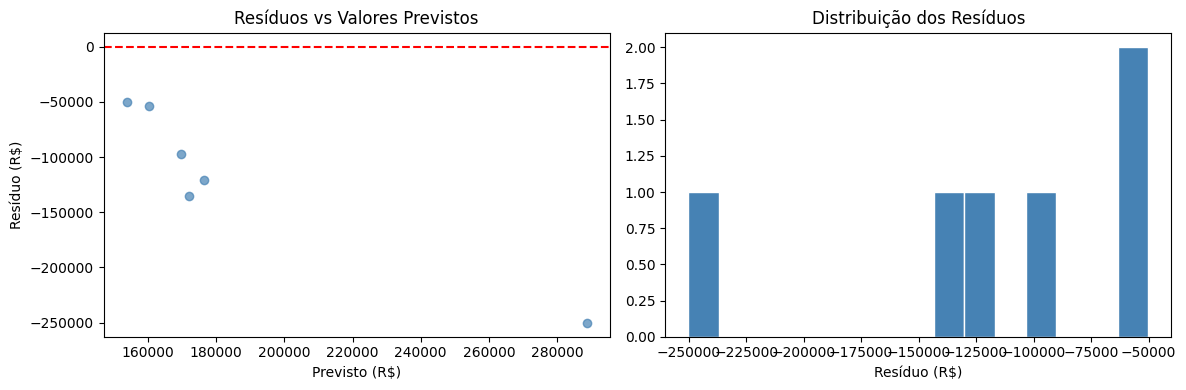

In [19]:
# === Resíduos ===
residuos = y_test_h1 - y_pred_best

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(y_pred_best, residuos, color='steelblue', alpha=0.7)
ax1.axhline(0, linestyle='--', color='red')
ax1.set_title('Resíduos vs Valores Previstos')
ax1.set_xlabel('Previsto (R$)')
ax1.set_ylabel('Resíduo (R$)')

ax2.hist(residuos, bins=15, color='steelblue', edgecolor='white')
ax2.set_title('Distribuição dos Resíduos')
ax2.set_xlabel('Resíduo (R$)')
plt.tight_layout()
plt.show()

In [21]:
# === PREVISÃO DOS PRÓXIMOS 3 MESES ===
from dateutil.relativedelta import relativedelta

# Pegar o último mês disponível na série
ultimo_mes = df_feat['ano_mes'].max()
mes1 = (ultimo_mes + 1).strftime('%b/%Y')
mes2 = (ultimo_mes + 2).strftime('%b/%Y')
mes3 = (ultimo_mes + 3).strftime('%b/%Y')

# Usar a última linha disponível como base para previsão
ultima_linha = df_feat[FEATURE_COLS].iloc[[-1]]

# Prever com o modelo otimizado (H+1)
prev_h1 = best_model_h1.predict(ultima_linha)[0]

# Para H+2 e H+3 usar os modelos candidatos treinados
model_h2 = trained[('GradientBoosting', 2)][0]
model_h3 = trained[('GradientBoosting', 3)][0]

prev_h2 = model_h2.predict(ultima_linha)[0]
prev_h3 = model_h3.predict(ultima_linha)[0]

print('=' * 45)
print('  📅 PREVISÃO DE CUSTO DE GARANTIA')
print('=' * 45)
print(f'  {mes1} (Mês+1):  R$ {prev_h1:>12,.2f}')
print(f'  {mes2} (Mês+2):  R$ {prev_h2:>12,.2f}')
print(f'  {mes3} (Mês+3):  R$ {prev_h3:>12,.2f}')
print('=' * 45)
print(f'  Total 3 meses:  R$ {prev_h1+prev_h2+prev_h3:>12,.2f}')
print('=' * 45)

  📅 PREVISÃO DE CUSTO DE GARANTIA
  Jun/2026 (Mês+1):  R$   267,759.07
  Jul/2026 (Mês+2):  R$   426,434.99
  Aug/2026 (Mês+3):  R$   426,434.99
  Total 3 meses:  R$ 1,120,629.04


## 10.1 Análise de erros e limitações

**Preencha após analisar os gráficos:**

- Os resíduos estão distribuídos de forma aleatória ou há padrão sistemático?
- O modelo erra mais nos meses de maior ou menor custo?
- Há sinais de overfitting (desempenho muito melhor no treino do que no teste)?
- Em quais situações o modelo não deveria ser usado?
- O que poderia melhorar o modelo (mais dados, mais features, outro algoritmo)?

**Resposta:**  
> _Preencha aqui._

---
# 11. Comparação Final dos Modelos

| Modelo | Horizonte | MAPE (%) | MAE (R$) | Observações |
|---|---|---:|---:|---|
| Baseline MM3 | H+1 | _preencha_ | _preencha_ | Referência mínima |
| Ridge | H+1 | _preencha_ | _preencha_ | Linear, rápido |
| Random Forest | H+1 | _preencha_ | _preencha_ | Não-linear |
| GradientBoosting | H+1 | _preencha_ | _preencha_ | Melhor candidato |
| GB Otimizado | H+1 | _preencha_ | _preencha_ | **Modelo final** |
| GB Otimizado | H+2 | _preencha_ | _preencha_ | Horizonte 2 |
| GB Otimizado | H+3 | _preencha_ | _preencha_ | Horizonte 3 |

> **Comentário:** preencha com os valores reais após executar o notebook com sua base.

---
# 12. Boas Práticas e Rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed 42 | Reprodutibilidade | Resultados idênticos em re-execuções |
| Divisão temporal (sem shuffle) | Evitar data leakage | Avaliação realista |
| Direct Multi-Step (3 modelos) | Evitar acumulação de erro | Previsões independentes por horizonte |
| TimeSeriesSplit na validação cruzada | Preservar ordem temporal no tuning | Hiperparâmetros sem vazamento |
| MAPE como métrica principal | Interpretável para o negócio (%) | Facilita comunicação com stakeholders |
| Features de lag 1, 2, 3, 6, 12 | Capturar tendência e sazonalidade anual | Melhora previsões de longo prazo |
| Média móvel como baseline | Benchmark simples e realista | Define o mínimo aceitável de desempenho |

---
# 13. Conclusão

**Preencha após executar o notebook com sua base real:**

- **Objetivo:** prever o custo total de garantia para os meses +1, +2 e +3 a partir do histórico de ordens de serviço.
- **Melhor solução encontrada:** _descreva o modelo e as métricas finais._
- **Comparação com baseline:** _o modelo superou a média móvel? Em quanto?_
- **Principais aprendizados:** _o que os dados ensinaram sobre o comportamento dos custos de garantia?_
- **Limitações:** _poucos meses de histórico? Dados faltantes? Eventos externos não capturados?_
- **Próximos passos:** _incluir features por modelo de produto, criar dashboard de monitoramento, re-treinar mensalmente._

**Conclusão:**  
> _Preencha aqui._

---
# 14. Salvamento de Artefatos (Opcional)

In [20]:
# Descomente para salvar o modelo final e os resultados

# import joblib
# joblib.dump(best_model_h1, 'modelo_garantia_h1.pkl')
# print('Modelo H+1 salvo.')

# df_compare.to_csv('resultados_modelos.csv', index=False)
# print('Tabela de resultados salva.')